# 01-4 图片怎么变成 Token

在 [上一节](./01-3-token_generates_token.ipynb) 中，我们搞清楚了文本 Token 如何一个接一个地生成。但世界不只是文本 —— 我们看图片、看视频、听声音，这些信息又是如何变成模型能理解的 Token 的呢？

本节我们将探索 **视觉 Token**：图片如何被切分为 Patch，再变成和文本 Token 同等地位的向量？

我们将使用 **Qwen3.5-0.8B** 模型作为实验对象 —— 它是 Qwen3.5 家族中最小的成员，但和所有 Qwen3.5 模型一样，**原生支持图片输入**，不需要单独的"VL"版本。我们会用可爱的 **乖乖** 图片来实际验证。

⏸ 关于视频和音频的 Token 化，我们将在后续章节中深入探讨。

In [1]:
from modelscope import snapshot_download
from transformers import AutoTokenizer, AutoProcessor, Qwen3_5ForConditionalGeneration, TextIteratorStreamer
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import sys
import logging
from threading import Thread

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()

tokenizer_id = "Qwen/Qwen3.5-0.8B"
model_dir = snapshot_download(tokenizer_id)
tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
processor = AutoProcessor.from_pretrained(model_dir, local_files_only=True)

print(f"模型: {tokenizer_id}")
print(f"词表大小: {len(tokenizer)}")
print(f"Processor 类型: {type(processor).__name__}")

模型: Qwen/Qwen3.5-0.8B
词表大小: 248077
Processor 类型: Qwen3VLProcessor


## 1. 视觉 Token：图片如何变成 Token？

在第一课中，我们看到文本通过 BPE 分词器被切分为 Token。那图片呢？图片是一个二维的像素矩阵，没有"空格"或"词边界"可以切分。

答案是 **ViT (Vision Transformer)** 思想：将图片切成固定大小的小块（Patch），每个小块就是一个"视觉 Token"。

具体过程如下：

1. **调整大小**：将输入图片调整到模型需要的分辨率。
2. **切分 Patch**：将图片切成 $P \times P$ 的小块（Qwen3.5 使用 $16 \times 16$ 的 Patch）。
3. **展平 + 线性映射**：每个 Patch 展平为一维向量，再通过一个线性层映射到与文本 Token 相同的维度。
4. **空间合并**：将相邻的 $2 \times 2$ 个 Patch 合并，减少 Token 数量，提高效率。
5. **添加位置编码**：为每个视觉 Token 加上位置信息，让模型知道它们在图片中的位置。

让我们用可爱的 **乖乖** 图片来直观感受这个过程：

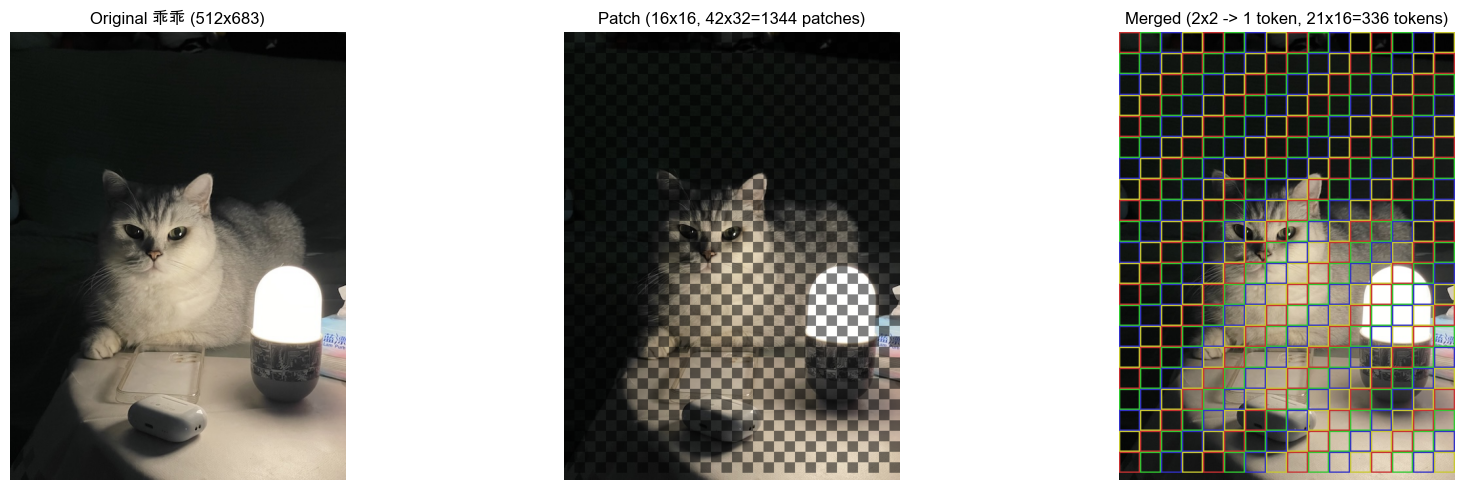


=== 视觉 Token 数量计算 ===
图片尺寸: 512x683
Patch 尺寸: 16x16
原始 Patch 数量: 42x32 = 1344
空间合并 (2x2): 21x16 = 336 个视觉 Token

对比: 同样的乖乖图片
  文本 Token: 一句话通常只有 10-30 个 Token
  视觉 Token: 一张图片就需要 336 个 Token!


In [2]:
demo_img_path = os.path.join(NOTEBOOK_DIR, "guaiguai.jpg")
demo_img = Image.open(demo_img_path)
img_w, img_h = demo_img.size

patch_size = 16
merge_size = 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(demo_img)
axes[0].set_title(f"Original 乖乖 ({img_w}x{img_h})")
axes[0].axis('off')

img_arr = np.array(demo_img)
patched = img_arr.copy()
n_patches_h = img_h // patch_size
n_patches_w = img_w // patch_size
for i in range(n_patches_h):
    for j in range(n_patches_w):
        if (i + j) % 2 == 0:
            patched[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] \
                = (patched[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] * 0.5).astype(np.uint8)
axes[1].imshow(patched)
axes[1].set_title(f"Patch ({patch_size}x{patch_size}, {n_patches_h}x{n_patches_w}={n_patches_h*n_patches_w} patches)")
axes[1].axis('off')

merged_h = n_patches_h // merge_size
merged_w = n_patches_w // merge_size
merged_vis = img_arr.copy()
colors = np.array([[200, 50, 50], [50, 200, 50], [50, 50, 200], [200, 200, 50]])
for i in range(merged_h):
    for j in range(merged_w):
        c = colors[(i + j) % 4]
        y1, y2 = i * patch_size * merge_size, (i + 1) * patch_size * merge_size
        x1, x2 = j * patch_size * merge_size, (j + 1) * patch_size * merge_size
        merged_vis[y1:y1+2, x1:x2] = c
        merged_vis[y2-2:y2, x1:x2] = c
        merged_vis[y1:y2, x1:x1+2] = c
        merged_vis[y1:y2, x2-2:x2] = c
if n_patches_h % merge_size != 0:
    y_start = merged_h * patch_size * merge_size
    y_end = n_patches_h * patch_size
    for j in range(merged_w):
        c = colors[(merged_h + j) % 4]
        x1, x2 = j * patch_size * merge_size, (j + 1) * patch_size * merge_size
        merged_vis[y_start:y_start+2, x1:x2] = c
        merged_vis[y_end-2:y_end, x1:x2] = c
        merged_vis[y_start:y_end, x1:x1+2] = c
        merged_vis[y_start:y_end, x2-2:x2] = c
if n_patches_w % merge_size != 0:
    x_start = merged_w * patch_size * merge_size
    x_end = n_patches_w * patch_size
    for i in range(merged_h):
        c = colors[(i + merged_w) % 4]
        y1, y2 = i * patch_size * merge_size, (i + 1) * patch_size * merge_size
        merged_vis[y1:y1+2, x_start:x_end] = c
        merged_vis[y2-2:y2, x_start:x_end] = c
        merged_vis[y1:y2, x_start:x_start+2] = c
        merged_vis[y1:y2, x_end-2:x_end] = c
if n_patches_h % merge_size != 0 and n_patches_w % merge_size != 0:
    c = colors[(merged_h + merged_w) % 4]
    y1, y2 = merged_h * patch_size * merge_size, n_patches_h * patch_size
    x1, x2 = merged_w * patch_size * merge_size, n_patches_w * patch_size
    merged_vis[y1:y1+2, x1:x2] = c
    merged_vis[y2-2:y2, x1:x2] = c
    merged_vis[y1:y2, x1:x1+2] = c
    merged_vis[y1:y2, x2-2:x2] = c
axes[2].imshow(merged_vis)
full_merged_h = merged_h + (1 if n_patches_h % merge_size != 0 else 0)
full_merged_w = merged_w + (1 if n_patches_w % merge_size != 0 else 0)
axes[2].set_title(f"Merged ({merge_size}x{merge_size} -> 1 token, {full_merged_h}x{full_merged_w}={full_merged_h*full_merged_w} tokens)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== 视觉 Token 数量计算 ===")
print(f"图片尺寸: {img_w}x{img_h}")
print(f"Patch 尺寸: {patch_size}x{patch_size}")
print(f"原始 Patch 数量: {n_patches_h}x{n_patches_w} = {n_patches_h*n_patches_w}")
print(f"空间合并 ({merge_size}x{merge_size}): {full_merged_h}x{full_merged_w} = {full_merged_h*full_merged_w} 个视觉 Token")
if n_patches_h % merge_size != 0 or n_patches_w % merge_size != 0:
    print(f"  注意: 图片尺寸不能被 {merge_size}*{patch_size} 整除，边缘 Patch 单独成组")
print(f"\n对比: 同样的乖乖图片")
print(f"  文本 Token: 一句话通常只有 10-30 个 Token")
print(f"  视觉 Token: 一张图片就需要 {full_merged_h*full_merged_w} 个 Token!")

### 视觉 Token 的特殊标记

和文本 Token 一样，视觉 Token 也有自己的"标点符号"。在 Qwen3.5 中，模型使用特殊的 Token ID 来标记视觉区域的开始和结束。让我们加载完整的多模态模型，查看它的配置：

In [3]:
model = Qwen3_5ForConditionalGeneration.from_pretrained(model_dir, local_files_only=True)
config = model.config

print("=== Qwen3.5 多模态特殊 Token ===")
special_ids = {
    "vision_start_token_id": config.vision_start_token_id,
    "vision_end_token_id": config.vision_end_token_id,
    "image_token_id": config.image_token_id,
    "video_token_id": config.video_token_id,
}
for name, tid in special_ids.items():
    decoded = tokenizer.decode([tid])
    print(f"  {name:25s} -> ID: {tid:6d}  解码: {decoded!r}")

print(f"\n=== 视觉编码器配置 ===")
vc = config.vision_config
print(f"  层数 (depth):       {vc.depth}")
print(f"  隐藏维度:      {vc.hidden_size}")
print(f"  Patch 尺寸:        {vc.patch_size}")
print(f"  空间合并尺寸:   {vc.spatial_merge_size}")
print(f"  时间 Patch 尺寸: {vc.temporal_patch_size}")
print(f"  输出维度:       {vc.out_hidden_size} (与文本模型对齐)")

print(f"\n=== 文本模型配置 ===")
tc = config.text_config
print(f"  层数:              {tc.num_hidden_layers}")
print(f"  隐藏维度:          {tc.hidden_size}")
print(f"  词表大小:          {tc.vocab_size}")
print(f"  最大位置编码:      {tc.max_position_embeddings}")
print(f"  共享词嵌入:      {tc.tie_word_embeddings}")

print(f"\n=== 模型结构 ===")
for name, child in model.named_children():
    print(f"  {name}: {type(child).__name__}")
    if name == "model":
        for sub_name, sub_child in child.named_children():
            print(f"    {sub_name}: {type(sub_child).__name__}")

print(f"\n小知识: Qwen3_5ForConditionalGeneration 包含视觉编码器 (visual) + 语言模型 (language_model) + 输出头 (lm_head)。")
print(f"使用 model.generate() 时，框架自动处理 KV Cache 和 mRoPE 位置编码，无需手动管理。")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

=== Qwen3.5 多模态特殊 Token ===
  vision_start_token_id     -> ID: 248053  解码: '<|vision_start|>'
  vision_end_token_id       -> ID: 248054  解码: '<|vision_end|>'
  image_token_id            -> ID: 248056  解码: '<|image_pad|>'
  video_token_id            -> ID: 248057  解码: '<|video_pad|>'

=== 视觉编码器配置 ===
  层数 (depth):       12
  隐藏维度:      768
  Patch 尺寸:        16
  空间合并尺寸:   2
  时间 Patch 尺寸: 2
  输出维度:       1024 (与文本模型对齐)

=== 文本模型配置 ===
  层数:              24
  隐藏维度:          1024
  词表大小:          248320
  最大位置编码:      262144
  共享词嵌入:      True

=== 模型结构 ===
  model: Qwen3_5Model
    visual: Qwen3_5VisionModel
    language_model: Qwen3_5TextModel
  lm_head: Linear

小知识: Qwen3_5ForConditionalGeneration 包含视觉编码器 (visual) + 语言模型 (language_model) + 输出头 (lm_head)。
使用 model.generate() 时，框架自动处理 KV Cache 和 mRoPE 位置编码，无需手动管理。


### 实战：用 Qwen3.5 处理乖乖图片

让我们用乖乖图片，看看 Qwen3.5 如何将它转化为 Token：

In [4]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "Please describe this image."},
        ],
    }
]

text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(f"=== 处理后的文本提示 ===")
print(text_prompt)
print(f"\n=== 特殊 Token 标记解读 ===")
img_tok = tokenizer.decode([config.image_token_id])
vis_start = tokenizer.decode([config.vision_start_token_id])
vis_end = tokenizer.decode([config.vision_end_token_id])
print(f"  {vis_start!r} 标记视觉区域的开始")
print(f"  {img_tok!r} 是单个视觉 Token 的占位符（实际会被重复多次，每个对应一个 Patch）")
print(f"  {vis_end!r} 标记视觉区域的结束")

image_inputs = processor(
    text=[text_prompt],
    images=[demo_img],
    return_tensors="pt",
)

input_ids = image_inputs["input_ids"][0]
print(f"\n=== Token ID 序列 ===")
print(f"总 Token 数: {len(input_ids)}")
print(f"\n逐段解码:")
decoded_segments = []
current_segment = []
for tid in input_ids.tolist():
    current_segment.append(tid)
    if tid in [config.vision_start_token_id, config.vision_end_token_id, config.image_token_id]:
        if len(current_segment) > 1:
            decoded_segments.append(("text", tokenizer.decode(current_segment[:-1]), len(current_segment) - 1))
        decoded_segments.append(("special", tokenizer.decode([tid]), 1))
        current_segment = []
if current_segment:
    decoded_segments.append(("text", tokenizer.decode(current_segment), len(current_segment)))

merged_segments = []
for seg in decoded_segments:
    if merged_segments and merged_segments[-1][0] == "special" and merged_segments[-1][1] == seg[1]:
        merged_segments[-1] = (seg[0], seg[1], merged_segments[-1][2] + seg[2])
    else:
        merged_segments.append(seg)

for seg_type, seg_text, seg_len in merged_segments:
    if seg_type == "special":
        count_str = f" (1 token)" if seg_len == 1 else f" ({seg_len} tokens)"
        repeat_str = f" x{seg_len}" if seg_len > 1 else ""
        print(f"  [{seg_type:8s}] {seg_text!r:20s}{repeat_str}{count_str}")
    else:
        preview = seg_text[:40] + "..." if len(seg_text) > 40 else seg_text
        print(f"  [{seg_type:8s}] {preview!r:40s} ({seg_len} tokens)")

img_token_count = (input_ids == config.image_token_id).sum().item()
print(f"\n视觉 Token (image_token) 数量: {img_token_count}")
print(f"文本 Token 数量: {len(input_ids) - img_token_count}")

=== 处理后的文本提示 ===
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Please describe this image.<|im_end|>
<|im_start|>assistant
<think>

</think>



=== 特殊 Token 标记解读 ===
  '<|vision_start|>' 标记视觉区域的开始
  '<|image_pad|>' 是单个视觉 Token 的占位符（实际会被重复多次，每个对应一个 Patch）
  '<|vision_end|>' 标记视觉区域的结束

=== Token ID 序列 ===
总 Token 数: 355

逐段解码:
  [text    ] '<|im_start|>user\n'                     (3 tokens)
  [special ] '<|vision_start|>'   (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_

### 图片分辨率如何影响 Token 数量？

和文本不同，图片的 Token 数量不是固定的，而是**取决于图片的分辨率和宽高比**。分辨率越高，需要的 Patch 越多，Token 数量也越多。这就是为什么在多模态模型中，高分辨率图片会消耗大量的 Token 配额。

In [5]:
sizes = [(112, 112), (224, 224), (448, 448), (672, 672)]

print(f"{'Size':>12s} | {'Pixels':>10s} | {'Visual Tokens':>14s} | {'~Chinese chars':>14s}")
print("-" * 60)

for w, h in sizes:
    img = Image.new('RGB', (w, h))
    msgs = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": "desc"}]}]
    prompt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt], images=[img], return_tensors="pt")
    n_vis = (inputs["input_ids"] == config.image_token_id).sum().item()
    n_zh = n_vis // 2
    print(f"{w}x{h} | {w*h:>10d} | {n_vis:>14d} | ~{n_zh}")

        Size |     Pixels |  Visual Tokens | ~Chinese chars
------------------------------------------------------------
112x112 |      12544 |             64 | ~32
224x224 |      50176 |             64 | ~32
448x448 |     200704 |            196 | ~98
672x672 |     451584 |            441 | ~220


## 2. 多模态融合：图片 Token 和文本 Token 如何共存？

现在我们已经了解了图片的 Token 是如何产生的。那它们在模型内部是如何与文本 Token "和平共处"的呢？

答案是：**所有模态的 Token 最终都被映射到同一个向量空间**，然后串接在一起，输入到同一个 Transformer 中处理。这就是"Everything is a Token"的真正含义。

具体来说，一个多模态输入的 Token 序列长这样：

```
[文本 Tokens] [vision_start] [视觉 Tokens...] [vision_end] [文本 Tokens] ...
```

关键设计：
- **视觉编码器** 的输出维度被映射为与文本 Embedding 相同的维度（Qwen3.5-0.8B 中是 1024）。
- **特殊标记 Token**（`vision_start`, `vision_end`）告诉模型"这里开始/结束是视觉内容"。
- **位置编码**：视觉 Token 使用特殊的 mRoPE（多维旋转位置编码），同时编码时间、竖直、水平三个维度的位置。
- **Transformer 不区分模态**：对 Transformer 来说，每个 Token 都是一个向量，无论它来自文本还是图片。

让我们用乖乖图片来验证这一点：

In [6]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "What is in this image?"},
        ],
    }
]

text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text_prompt], images=[demo_img], return_tensors="pt")
input_ids = inputs["input_ids"][0]

print("=== 多模态 Token 序列结构 ===")
print(f"总 Token 数: {len(input_ids)}")

segments = []
current_type = None
current_start = 0

for idx, tid in enumerate(input_ids.tolist()):
    if tid == config.vision_start_token_id:
        if current_type and idx > current_start:
            segments.append((current_type, current_start, idx))
        current_type = "vision_start"
        current_start = idx
    elif tid == config.vision_end_token_id:
        if current_type and idx > current_start:
            segments.append((current_type, current_start, idx))
        current_type = "vision_end"
        current_start = idx
    elif tid == config.image_token_id:
        if current_type != "image":
            if current_type and idx > current_start:
                segments.append((current_type, current_start, idx))
            current_type = "image"
            current_start = idx
    else:
        if current_type != "text":
            if current_type and idx > current_start:
                segments.append((current_type, current_start, idx))
            current_type = "text"
            current_start = idx

if current_type and len(input_ids) > current_start:
    segments.append((current_type, current_start, len(input_ids)))

merged = []
for seg in segments:
    if merged and merged[-1][0] == seg[0]:
        merged[-1] = (seg[0], merged[-1][1], seg[2])
    else:
        merged.append(seg)

print(f"\n分段解读:")
type_labels = {
    "text": "文本",
    "image": "视觉",
    "vision_start": "视觉起始",
    "vision_end": "视觉结束",
}
for seg_type, start, end in merged:
    label = type_labels.get(seg_type, seg_type)
    n = end - start
    if seg_type == "text":
        text_content = tokenizer.decode(input_ids[start:end])
        preview = text_content[:50].replace('\n', '\\n')
        print(f"  [{label:6s}] pos {start:>3d}-{end-1:>3d} ({n:>3d} tokens): {preview!r}")
    else:
        print(f"  [{label:6s}] pos {start:>3d}-{end-1:>3d} ({n:>3d} tokens)")

print(f"\n=== 向量维度验证 ===")
text_embed_dim = config.text_config.hidden_size
vision_out_dim = config.vision_config.out_hidden_size
print(f"文本 Embedding 维度:    {text_embed_dim}")
print(f"视觉编码器输出维度: {vision_out_dim}")
print(f"两者一致: {text_embed_dim == vision_out_dim}")
print(f"\n这意味着视觉 Token 和文本 Token 在同一个向量空间中，Transformer 对它们一视同仁。")

=== 多模态 Token 序列结构 ===
总 Token 数: 356

分段解读:
  [文本    ] pos   0-  2 (  3 tokens): '<|im_start|>user\\n'
  [视觉起始  ] pos   3-  3 (  1 tokens)
  [视觉    ] pos   4-339 (336 tokens)
  [视觉结束  ] pos 340-340 (  1 tokens)
  [文本    ] pos 341-355 ( 15 tokens): 'What is in this image?<|im_end|>\\n<|im_start|>assis'

=== 向量维度验证 ===
文本 Embedding 维度:    1024
视觉编码器输出维度: 1024
两者一致: True

这意味着视觉 Token 和文本 Token 在同一个向量空间中，Transformer 对它们一视同仁。


### 多模态流式推理（带 KV Cache 加速）

最后，让我们用 Qwen3.5-0.8B 完成一次真正的多模态推理，看看模型能不能"看懂" 乖乖图片并回答问题。

**KV Cache 加速原理**：自回归生成中，每一步都要对整个序列做注意力计算。但前面已经算过的 Token 的 Key/Value 是不会变的！把它们缓存起来就是 **KV Cache** —— 每步只算新 Token 的 K/V，然后和缓存的 K/V 一起做注意力。每步计算量从 O(N) 降到 O(1)，总体从 O(N²) 降到 O(N)。对于多模态模型效果尤其显著，因为一张图片就有 336 个视觉 Token，视频更是 1664 个，重复计算它们的开销非常大。

我们使用 `model.generate()` + `TextIteratorStreamer` 实现流式输出，框架自动处理 KV Cache 和 Qwen3.5 特有的 mRoPE 位置编码。同时通过 `/no_think` 关闭思考模式（让模型直接回答），并使用 Qwen3.5 推荐的非思考模式采样参数（temperature=0.7, top_p=0.8, top_k=20）：

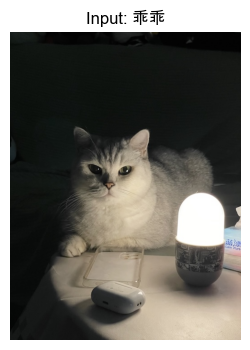

提问: 你从图里看到了什么？挑重点，禁止啰嗦 /no_think
输入 Token 数（图片+提示词）: 367

流式生成中: 

🐱 

一只

灰

白

...

又

略带

警觉

。



【结束啦】耗时 377.4s


In [7]:
question = "你从图里看到了什么？挑重点，禁止啰嗦 /no_think"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": question},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title("Input: 乖乖")
plt.axis('off')
plt.show()

print(f"提问: {question}")
print(f"输入 Token 数（图片+提示词）: {inputs['input_ids'].numel()}")
print(f"\n流式生成中: ", end="", flush=True)

streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

generation_kwargs = dict(
    **inputs,
    streamer=streamer,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

import time
t0 = time.time()

thread = Thread(target=model.generate, kwargs=generation_kwargs)
thread.start()

for new_text in streamer:
    print(new_text, end="", flush=True)

thread.join()
elapsed = time.time() - t0
print(f"\n【结束啦】耗时 {elapsed:.1f}s")

## 小结

本节我们深入探索了图片如何变成 Token：

| 步骤 | 操作 | 结果 |
|------|------|------|
| 1 | 调整图片大小 | 统一到模型需要的分辨率 |
| 2 | 切分 Patch (16×16) | 每个Patch是一个"视觉词" |
| 3 | 展平 + 线性映射 | 映射到与文本Token相同的维度 |
| 4 | 空间合并 (2×2) | 减少Token数量，提高效率 |
| 5 | 添加位置编码 | 让模型知道每个Token的位置 |

核心洞察：**视觉 Token 和文本 Token 在同一个向量空间中，Transformer 对它们一视同仁。** 这就是"Everything is a Token"在视觉领域的体现。

👉 下一节：[01-5 视频怎么变成 Token](./01-5-video_to_token.ipynb)